<a href="https://colab.research.google.com/github/SiyumiJayawardhane/freshsense-imagemodel/blob/sithmi/Food_Spoilage_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Core data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for model selection, preprocessing, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Machine learning models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# For handling imbalanced datasets (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE

# For saving and loading models
import joblib

## 1. Setup and Data Loading

In [2]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# Define the file path to the dataset
file_path = '/content/drive/MyDrive/TemperatureDataset.csv'
# Load the dataset into a pandas DataFrame
df = pd.read_csv(file_path)

# Print basic information about the loaded dataset
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
print("First 5 rows of the dataset:")
# Rename columns for better readability and consistency
df.columns = ['Fruit', 'Temp', 'Humidity', 'MQ135', 'MQ3', 'Time']
# Display the first few rows of the DataFrame with new column names
print(df.head())

Mounted at /content/drive
Dataset loaded with 4558 rows and 6 columns.
First 5 rows of the dataset:
                                              Fruit  Temp  Humidity  MQ135  \
0  spoiled banana, spoiled cucumber, spoiled tomato  16.2      66.6      0   
1  spoiled banana, spoiled cucumber, spoiled tomato  16.2      67.8      0   
2  spoiled banana, spoiled cucumber, spoiled tomato  16.2      68.2      0   
3  spoiled banana, spoiled cucumber, spoiled tomato  16.3      67.3      0   
4  spoiled banana, spoiled cucumber, spoiled tomato  16.3      67.5      0   

    MQ3                 Time  
0  1188    4/6/2026 13:26:30  
1  1217  2026-04-06 13:28:44  
2  1157  2026-04-06 13:30:01  
3  1309  2026-04-06 13:45:01  
4  1337  2026-04-06 13:51:58  


In [3]:
# Display the initial dimensions (rows, columns) of the DataFrame
print("Initial shape:", df.shape)

Initial shape: (4558, 6)


## 2. Data Preprocessing and Feature Engineering

In [4]:
# Define a function to extract the main fruit type from the 'Fruit' column
def extract_fruit(text):
    # Convert text to lowercase for case-insensitive matching
    text = str(text).lower()
    # Check for specific fruit keywords
    if "banana" in text:
        return "banana"
    elif "cucumber" in text:
        return "cucumber"
    elif "tomato" in text:
        return "tomato"
    else:
        return "other" # Categorize as 'other' if no specific fruit is found

# Apply the function to the 'Fruit' column to standardize fruit names
df['Fruit'] = df['Fruit'].apply(extract_fruit)

In [5]:
# Define thresholds for MQ3 sensor readings to determine spoilage status
mq3_low = 800  # Threshold: below 800 indicates 'fresh'
mq3_high = 1200 # Threshold: 800-1199 indicates 'at-risk', 1200+ indicates 'spoiled'

# Define a function to assign a spoilage status based on the 'MQ3' sensor reading
def create_status(row):
    if row['MQ3'] >= mq3_high:
        return "spoiled"
    elif row['MQ3'] >= mq3_low:
        return "at-risk"
    else:
        return "fresh"

# Apply the 'create_status' function row-wise to create a new 'Status' column
df['Status'] = df.apply(create_status, axis=1)

In [6]:
# Define a robust function to parse datetime strings that might be in multiple formats
def parse_multiple_formats(series, formats):
    # Initialize a new series with NaT (Not a Time) values
    parsed_series = pd.Series(pd.NaT, index=series.index)
    for fmt in formats:
        # Identify rows that are still unparsed (NaT)
        unparsed_mask = parsed_series.isna()
        if unparsed_mask.any():
            # Attempt to parse unparsed rows with the current format
            parsed_series[unparsed_mask] = pd.to_datetime(
                series[unparsed_mask], format=fmt, errors='coerce' # 'coerce' turns unparseable dates into NaT
            )
    return parsed_series

# Define a list of possible datetime formats present in the 'Time' column
datetime_formats = [
    '%m/%d/%Y %H:%M:%S', # Format: Month/Day/Year Hour:Minute:Second
    '%Y-%m-%d %H:%M:%S', # Format: Year-Month-Day Hour:Minute:Second
    '%Y-%m-%d %H:%M:%S.%f' # Format: Year-Month-Day Hour:Minute:Second.Microsecond
]

# Apply the parsing function to the 'Time' column to convert it to datetime objects
df['Time'] = parse_multiple_formats(df['Time'], datetime_formats)

In [7]:
# Display concise summary of the DataFrame, including data types and non-null values
print(df.info())
# Display descriptive statistics for numerical columns
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4558 entries, 0 to 4557
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Fruit     4558 non-null   object        
 1   Temp      4558 non-null   float64       
 2   Humidity  4558 non-null   float64       
 3   MQ135     4558 non-null   int64         
 4   MQ3       4558 non-null   int64         
 5   Time      4558 non-null   datetime64[ns]
 6   Status    4558 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 249.4+ KB
None
              Temp     Humidity        MQ135          MQ3  \
count  4558.000000  4558.000000  4558.000000  4558.000000   
mean     22.772049    74.204015    19.322071  1099.799473   
min      12.000000    50.600000     0.000000   308.000000   
25%      16.000000    67.825000     0.000000   741.000000   
50%      18.000000    74.500000     0.000000   962.000000   
75%      31.600000    79.8

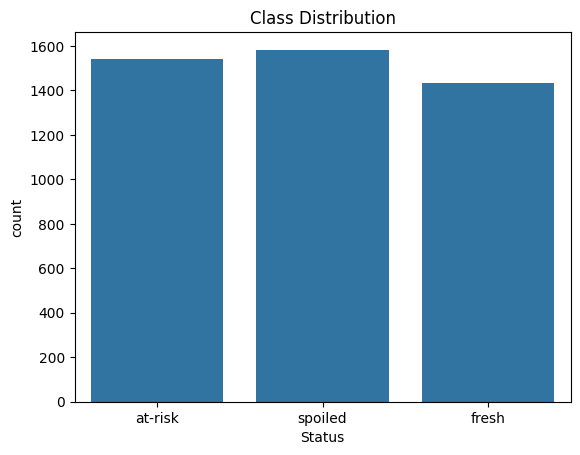

In [8]:
# Create a count plot to visualize the distribution of 'Status' (class distribution)
sns.countplot(x='Status', data=df)
# Set the title of the plot
plt.title("Class Distribution")
# Display the plot
plt.show()

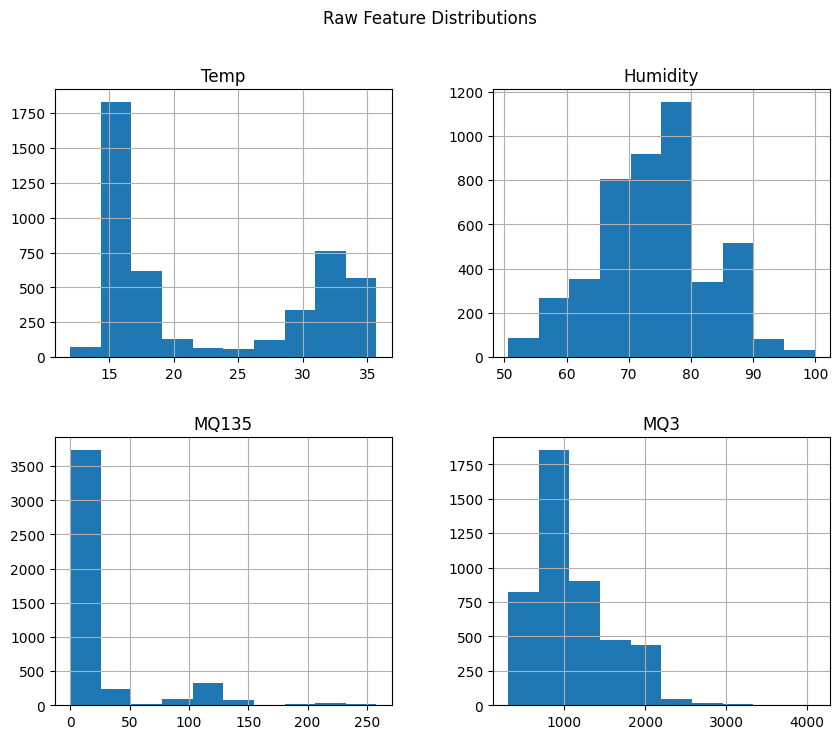

In [9]:
# Plot histograms for selected numerical features to observe their distributions
df[['Temp','Humidity','MQ135','MQ3']].hist(figsize=(10,8))
# Set a common title for all subplots (histograms)
plt.suptitle("Raw Feature Distributions")
# Display the plot
plt.show()

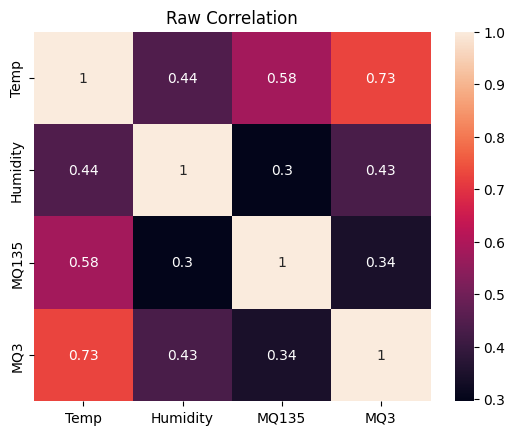

In [10]:
# Calculate the correlation matrix for selected numerical features
# and visualize it using a heatmap for 'Raw Correlation'
sns.heatmap(df[['Temp','Humidity','MQ135','MQ3']].corr(), annot=True)
# Set the title of the heatmap
plt.title("Raw Correlation")
# Display the plot
plt.show()

In [12]:
# Extract the hour of the day from the 'Time' column
df['hour'] = df['Time'].dt.hour
# Calculate elapsed minutes from the earliest timestamp in the 'Time' column
df['elapsed_min'] = (df['Time'] - df['Time'].min()).dt.total_seconds()/60

In [13]:
# Calculate the difference between consecutive MQ3 readings, filling the first NaN with 0
df['MQ3_diff'] = df['MQ3'].diff().fillna(0)
# Calculate the difference between consecutive MQ135 readings, filling the first NaN with 0
df['MQ135_diff'] = df['MQ135'].diff().fillna(0)

# Calculate a 3-period rolling mean for MQ3 readings, backfilling initial NaNs
df['MQ3_roll'] = df['MQ3'].rolling(3).mean().bfill()
# Calculate a 3-period rolling mean for MQ135 readings, backfilling initial NaNs
df['MQ135_roll'] = df['MQ135'].rolling(3).mean().bfill()

In [14]:
# Apply one-hot encoding to the 'Fruit' column, converting categorical text into numerical format
df = pd.get_dummies(df, columns=['Fruit'])

In [15]:
# Initialize LabelEncoder for converting categorical labels to numerical ones
le = LabelEncoder()
# Fit LabelEncoder to the 'Status' column and transform it to numerical labels
df['Status'] = le.fit_transform(df['Status'])

In [16]:
# Drop the original 'Time' column as time-based features have already been extracted
df = df.drop(columns=[ 'Time'])

## 3. Exploratory Data Analysis (EDA)

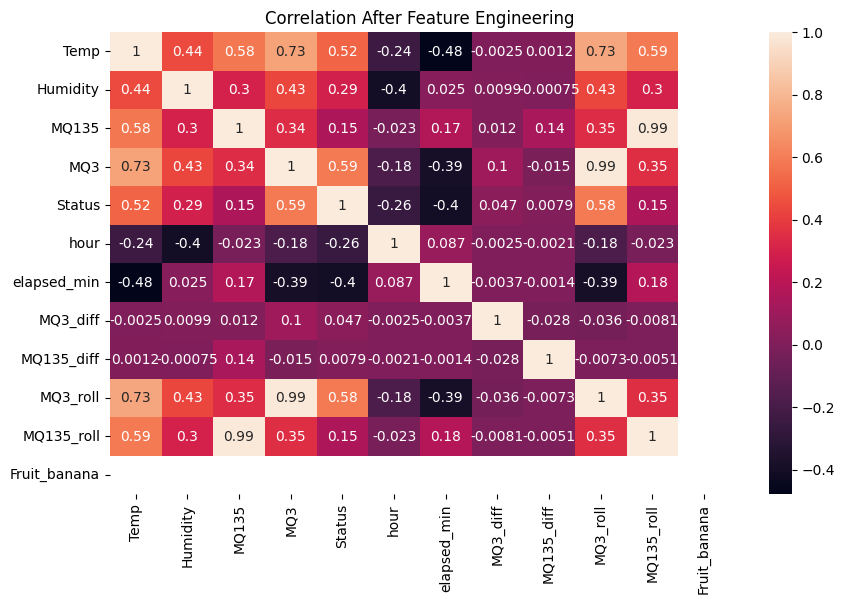

In [17]:
# Set the figure size for the heatmap
plt.figure(figsize=(10,6))
# Compute and plot the correlation matrix of the DataFrame after feature engineering
sns.heatmap(df.corr(), annot=True)
# Set the title of the heatmap
plt.title("Correlation After Feature Engineering")
# Display the plot
plt.show()

In [18]:
# Print the counts of each unique value in the 'Status' column
print(df['Status'].value_counts())

Status
2    1583
0    1541
1    1434
Name: count, dtype: int64


## 4. Model Preparation

In [19]:
# Define features (X) by dropping the 'Status' column
X = df.drop('Status', axis=1)
# Define target variable (y) as the 'Status' column
y = df['Status']

# Split the dataset into training and testing sets
# test_size=0.2 means 20% of data for testing, 80% for training
# random_state for reproducibility of the split
# stratify=y ensures that the proportion of target classes is the same in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Impute Missing Values

Before applying SMOTE, we need to handle any remaining `NaN` values in `X_train` and `X_test`. These often arise from feature engineering steps, particularly when dealing with time-related features where original `NaT` values propagate. Using median imputation is a good approach for numerical features as it is less sensitive to outliers than mean imputation.

In [20]:
from sklearn.impute import SimpleImputer

# Identify numerical columns in X_train that contain NaN values
numerical_cols_with_nan = X_train.select_dtypes(include=np.number).columns[X_train.select_dtypes(include=np.number).isnull().any()].tolist()

# Dictionary to store median values for imputation, to be used consistently during prediction
median_imputation_values = {}
for col in numerical_cols_with_nan:
    median_val = X_train[col].median()
    median_imputation_values[col] = median_val
    # Fill NaN values in training set with the column's median
    X_train[col] = X_train[col].fillna(median_val)
    # Fill NaN values in testing set with the training set's median for consistency
    X_test[col] = X_test[col].fillna(median_val)


# Initialize StandardScaler for feature scaling (standardization)
scaler = StandardScaler()
# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames, retaining column names
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Verify that no NaN values remain after imputation
print("NaN values after imputation in X_train:", X_train.isnull().sum().sum())
print("NaN values after imputation in X_test:", X_test.isnull().sum().sum())

NaN values after imputation in X_train: 0
NaN values after imputation in X_test: 0


In [21]:
# Print the class distribution before applying SMOTE
print("Before SMOTE:", np.bincount(y_train))

# Initialize SMOTE (Synthetic Minority Over-sampling Technique) to address class imbalance
sm = SMOTE()
# Apply SMOTE to the training data to balance class distribution
X_train, y_train = sm.fit_resample(X_train, y_train)

# Print the class distribution after applying SMOTE
print("After SMOTE:", np.bincount(y_train))

Before SMOTE: [1233 1147 1266]
After SMOTE: [1266 1266 1266]


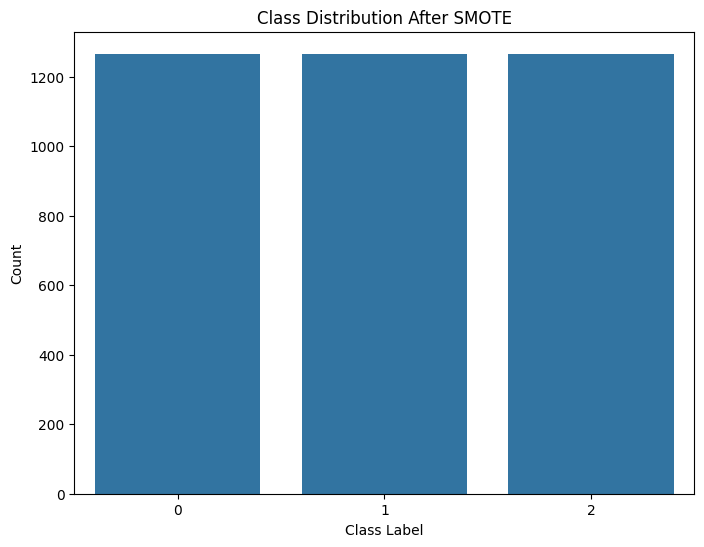

In [22]:
# Set the figure size for the plot
plt.figure(figsize=(8, 6))
# Create a count plot to visualize the class distribution after SMOTE
sns.countplot(x=y_train)
# Set the title of the plot
plt.title('Class Distribution After SMOTE')
# Set the x-axis label
plt.xlabel('Class Label')
# Set the y-axis label
plt.ylabel('Count')
# Display the plot
plt.show()

## 5. Model Training and Hyperparameter Tuning

In [23]:
# Initialize a RandomForestClassifier with 200 estimators and a fixed random state for reproducibility
rf = RandomForestClassifier(n_estimators=200, random_state=42)
# Train the Random Forest model on the balanced training data
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [25]:
# Initialize an XGBoost Classifier with 'mlogloss' as the evaluation metric for multiclass classification
xgb = XGBClassifier(eval_metric='mlogloss')
# Train the XGBoost model on the balanced training data
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

### Cross-Validation and Hyperparameter Tuning

#### Random Forest Hyperparameter Tuning

In [26]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define the parameter grid for Random Forest hyperparameter tuning
param_grid_rf = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [None, 10, 20],     # Maximum depth of the tree (None means unlimited)
    'min_samples_split': [2, 5, 10]  # Minimum number of samples required to split an internal node
}

# Initialize StratifiedKFold for cross-validation to maintain class distribution across folds
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Initialize GridSearchCV for Random Forest
# estimator: the model to tune
# param_grid: dictionary of parameters to test
# cv: cross-validation strategy
# scoring: metric to optimize ('accuracy')
# n_jobs=-1: use all available CPU cores
# verbose: controls the verbosity of the output
grid_search_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                            param_grid=param_grid_rf,
                            cv=skf,
                            scoring='accuracy',
                            n_jobs=-1,
                            verbose=1)

# Fit the GridSearchCV to the training data to find the best parameters
grid_search_rf.fit(X_train, y_train)

# Print the best parameters found by GridSearchCV
print("Best parameters for Random Forest:", grid_search_rf.best_params_)
# Print the best cross-validation score achieved with the best parameters
print("Best cross-validation score for Random Forest:", grid_search_rf.best_score_)

# Store the best Random Forest model found by GridSearchCV
best_rf_model = grid_search_rf.best_estimator_

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score for Random Forest: 0.9997367035281727


#### XGBoost Hyperparameter Tuning

In [27]:
# Define the parameter grid for XGBoost hyperparameter tuning
param_grid_xgb = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds (trees)
    'max_depth': [3, 5, 7],           # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2] # Step size shrinkage to prevent overfitting
}

# Initialize GridSearchCV for XGBoost
# estimator: XGBClassifier with eval_metric and random_state, use_label_encoder=False for newer XGBoost versions
# param_grid: dictionary of parameters to test
# cv: cross-validation strategy (using the same StratifiedKFold as for RF)
# scoring: metric to optimize ('accuracy')
# n_jobs=-1: use all available CPU cores
# verbose: controls the verbosity of the output
grid_search_xgb = GridSearchCV(estimator=XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42),
                             param_grid=param_grid_xgb,
                             cv=skf,
                             scoring='accuracy',
                             n_jobs=-1,
                             verbose=1)

# Fit the GridSearchCV to the training data to find the best parameters
grid_search_xgb.fit(X_train, y_train)

# Print the best parameters found by GridSearchCV for XGBoost
print("Best parameters for XGBoost:", grid_search_xgb.best_params_)
# Print the best cross-validation score achieved with the best parameters for XGBoost
print("Best cross-validation score for XGBoost:", grid_search_xgb.best_score_)

# Store the best XGBoost model found by GridSearchCV
best_xgb_model = grid_search_xgb.best_estimator_

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:42:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Best cross-validation score for XGBoost: 0.9978936282253817


## 6. Model Evaluation and Analysis


Random Forest
Train Accuracy: 1.0
Test Accuracy: 0.9978070175438597

Classification Report:
               precision    recall  f1-score   support

     at-risk       0.99      1.00      1.00       308
       fresh       1.00      1.00      1.00       287
     spoiled       1.00      0.99      1.00       317

    accuracy                           1.00       912
   macro avg       1.00      1.00      1.00       912
weighted avg       1.00      1.00      1.00       912



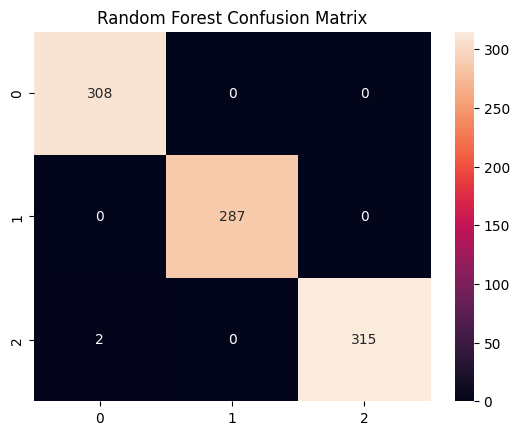


XGBoost
Train Accuracy: 1.0
Test Accuracy: 0.9967105263157895

Classification Report:
               precision    recall  f1-score   support

     at-risk       0.99      1.00      1.00       308
       fresh       1.00      1.00      1.00       287
     spoiled       1.00      0.99      1.00       317

    accuracy                           1.00       912
   macro avg       1.00      1.00      1.00       912
weighted avg       1.00      1.00      1.00       912



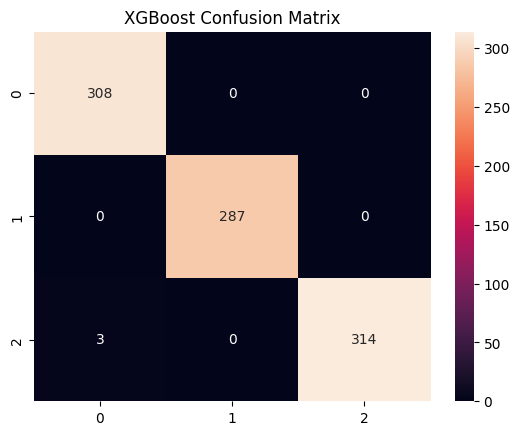

In [28]:
# Define a function to evaluate a given model and print its performance metrics
def evaluate(model, name):
    # Make predictions on the training set
    y_train_pred = model.predict(X_train)
    # Make predictions on the test set
    y_test_pred = model.predict(X_test)

    # Print the model name
    print(f"\n{name}")
    # Print training accuracy
    print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
    # Print test accuracy
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

    # LabelEncoder sorts classes alphabetically: 'at-risk', 'fresh', 'spoiled'
    # So, numerical labels 0, 1, 2 correspond to these strings respectively.
    class_names = ['at-risk', 'fresh', 'spoiled']
    # Print the classification report for detailed precision, recall, f1-score
    print("\nClassification Report:\n",
          classification_report(y_test, y_test_pred, target_names=class_names))

    # Plot the confusion matrix for visual evaluation of predictions
    sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d')
    # Set the title of the confusion matrix plot
    plt.title(name + " Confusion Matrix")
    # Display the plot
    plt.show()

# Evaluate the initial Random Forest model
evaluate(rf, "Random Forest")
# Evaluate the initial XGBoost model
evaluate(xgb, "XGBoost")

### Evaluation of Tuned Models


Tuned Random Forest
Train Accuracy: 1.0
Test Accuracy: 0.9967105263157895

Classification Report:
               precision    recall  f1-score   support

     at-risk       0.99      1.00      1.00       308
       fresh       1.00      1.00      1.00       287
     spoiled       1.00      0.99      1.00       317

    accuracy                           1.00       912
   macro avg       1.00      1.00      1.00       912
weighted avg       1.00      1.00      1.00       912



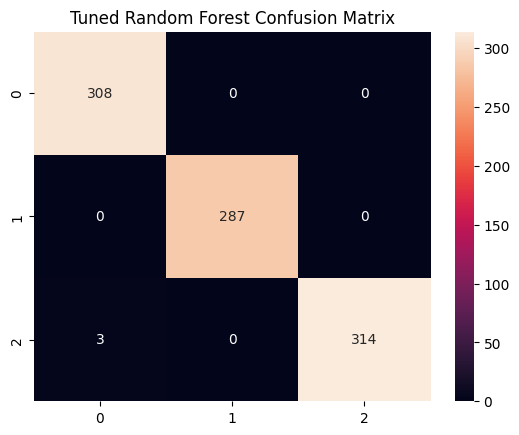


Tuned XGBoost
Train Accuracy: 0.9976303317535545
Test Accuracy: 0.9967105263157895

Classification Report:
               precision    recall  f1-score   support

     at-risk       0.99      1.00      1.00       308
       fresh       1.00      1.00      1.00       287
     spoiled       1.00      0.99      1.00       317

    accuracy                           1.00       912
   macro avg       1.00      1.00      1.00       912
weighted avg       1.00      1.00      1.00       912



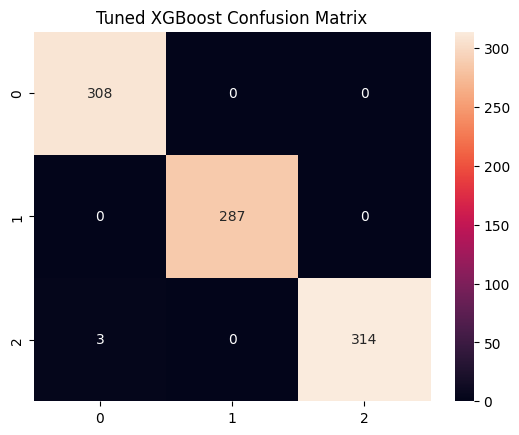

In [29]:
# Evaluate the Random Forest model with optimized hyperparameters
evaluate(best_rf_model, "Tuned Random Forest")

# Evaluate the XGBoost model with optimized hyperparameters
evaluate(best_xgb_model, "Tuned XGBoost")

In [31]:
# Define a function to check for overfitting by comparing train and test accuracies
def check_overfitting(model, name):
    # Calculate training accuracy
    train_acc = accuracy_score(y_train, model.predict(X_train))
    # Calculate testing accuracy
    test_acc = accuracy_score(y_test, model.predict(X_test))

    # Print the model name and accuracies
    print(f"\n{name} Overfitting Check")
    print("Train:", train_acc)
    print("Test:", test_acc)

    # Check if the difference between train and test accuracy is significant (e.g., > 0.1)
    if train_acc - test_acc > 0.1:
        print("⚠️ Overfitting detected")
    else:
        print("✅ Good generalization")

# Check overfitting for the initial Random Forest model
check_overfitting(rf, "Random Forest")
# Check overfitting for the initial XGBoost model
check_overfitting(xgb, "XGBoost")


Random Forest Overfitting Check
Train: 1.0
Test: 0.9978070175438597
✅ Good generalization

XGBoost Overfitting Check
Train: 1.0
Test: 0.9967105263157895
✅ Good generalization


In [33]:
# Check overfitting for tuned models
check_overfitting(best_rf_model, "Tuned Random Forest")
check_overfitting(best_xgb_model, "Tuned XGBoost")


Tuned Random Forest Overfitting Check
Train: 1.0
Test: 0.9967105263157895
✅ Good generalization

Tuned XGBoost Overfitting Check
Train: 0.9976303317535545
Test: 0.9967105263157895
✅ Good generalization


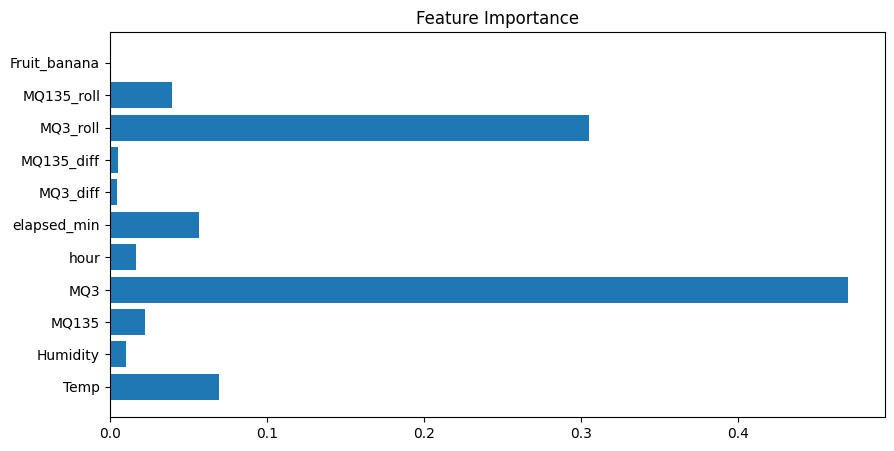

In [34]:
# Get feature importances from the trained Random Forest model
importances = rf.feature_importances_

# Create a horizontal bar plot to visualize feature importances
plt.figure(figsize=(10,5))
plt.barh(X.columns, importances)
# Set the title of the plot
plt.title("Feature Importance")
# Display the plot
plt.show()

## 7. Model Persistence and Prediction

In [35]:
# Save the trained Random Forest model to a file using joblib
joblib.dump(rf, "rf_model.pkl")
# Save the fitted StandardScaler to a file
joblib.dump(scaler, "scaler.pkl")
# Save the fitted LabelEncoder to a file
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [37]:
# Define an improved function to predict the spoilage status of a new sample
def predict_sample(sample_dict):
    # Convert the input dictionary into a pandas DataFrame
    input_df = pd.DataFrame([sample_dict])

    # Reindex the input DataFrame to ensure all feature columns from training are present,
    # filling any new columns (features not in sample_dict) with 0
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    # Apply median imputation for 'hour' and 'elapsed_min' if they were missing in the input sample
    # Use the median_imputation_values captured from the training set to ensure consistency
    for col, median_val in median_imputation_values.items():
        if col in input_df.columns:
            # Assign directly instead of using inplace=True to avoid FutureWarning
            input_df[col] = input_df[col].fillna(median_val)

    # Convert to DataFrame with column names before scaling to maintain feature names.
    # This helps avoid the UserWarning from sklearn about missing feature names during prediction.
    input_df_scaled = pd.DataFrame(scaler.transform(input_df), columns=input_df.columns)

    # Make a prediction using the trained Random Forest model
    pred = rf.predict(input_df_scaled)

    # Explicitly map the numerical prediction back to its original string label
    # Based on LabelEncoder's alphabetical sorting: 0='at-risk', 1='fresh', 2='spoiled'
    class_names = ['at-risk', 'fresh', 'spoiled']
    return class_names[pred[0]]


# Example sample dictionary for prediction, simulating a 'spoiled' scenario
sample = {
    'Temp': 28,
    'Humidity': 70,
    'MQ135': 15,
    'MQ3': 1800, # High MQ3 value indicating spoilage
    'hour': 14,
    'elapsed_min': 500,
    'MQ3_diff': 100,
    'MQ135_diff': 5,
    'MQ3_roll': 1600,
    'MQ135_roll': 10,
    'Fruit_banana': 0,
    'Fruit_cucumber': 1,
    'Fruit_tomato': 0,
    'Fruit_other': 0
}

# Print the prediction for the example sample
print("Prediction:", predict_sample(sample))

Prediction: spoiled


In [38]:
# Sample input for 'fresh' prediction (MQ3 value is below the 'mq3_low' threshold)
sample_fresh = {
    'Temp': 20,
    'Humidity': 60,
    'MQ135': 5,
    'MQ3': 700, # Value below mq3_low (800) -> expected 'fresh'
    'hour': 10,
    'elapsed_min': 200,
    'MQ3_diff': -50,
    'MQ135_diff': -2,
    'MQ3_roll': 720,
    'MQ135_roll': 4,
    'Fruit_banana': 1,
    'Fruit_cucumber': 0,
    'Fruit_tomato': 0,
    'Fruit_other': 0
}

# Get and print the prediction for the 'fresh' sample
print("Prediction for 'fresh' sample:", predict_sample(sample_fresh))

Prediction for 'fresh' sample: fresh


In [39]:
# Sample input for 'at-risk' prediction (MQ3 value is between 'mq3_low' and 'mq3_high' thresholds)
sample_at_risk = {
    'Temp': 25,
    'Humidity': 75,
    'MQ135': 10,
    'MQ3': 950, # Value between mq3_low (800) and mq3_high (1200) -> expected 'at-risk'
    'hour': 16,
    'elapsed_min': 700,
    'MQ3_diff': 20,
    'MQ135_diff': 1,
    'MQ3_roll': 930,
    'MQ135_roll': 9,
    'Fruit_banana': 0,
    'Fruit_cucumber': 0,
    'Fruit_tomato': 1,
    'Fruit_other': 0
}

# Get and print the prediction for the 'at-risk' sample
print("Prediction for 'at-risk' sample:", predict_sample(sample_at_risk))

Prediction for 'at-risk' sample: at-risk
